In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
import joblib
import os

print("✅ Libraries imported!")

✅ Libraries imported!


In [4]:
X_train = pd.read_csv('../data/processed/X_train_final.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
y_val   = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✅ Data loaded!")
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

✅ Data loaded!
X_train shape: (107748, 41)
X_val shape:   (26938, 41)
X_test shape:  (22544, 41)


In [5]:
from sklearn.svm import SVC

# Use 20k sample for speed — SVM is slow on large data
X_train_sample = X_train.sample(n=20000, random_state=42)
y_train_sample = y_train[X_train_sample.index]

print("⏳ Training SVM... (may take 5-10 minutes)")

svm_model = SVC(
    kernel='rbf',        # RBF kernel — best for this type of data
    C=1.0,               # regularization
    gamma='scale',       # auto scale gamma
    probability=True,    # needed for ROC curve
    random_state=42,
    verbose=True
)

svm_model.fit(X_train_sample, y_train_sample)
print("✅ SVM trained!")

⏳ Training SVM... (may take 5-10 minutes)
[LibSVM]✅ SVM trained!


In [6]:
y_pred = svm_model.predict(X_val)
y_prob = svm_model.predict_proba(X_val)[:, 1]

print("=" * 45)
print("           SVM RESULTS")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_val, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_val, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_val, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_val, y_pred)*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob)*100:.2f}%")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomaly']))

           SVM RESULTS
Accuracy:  96.09%
Precision: 98.68%
Recall:    93.44%
F1-Score:  95.99%
AUC-ROC:   99.16%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96     13469
     Anomaly       0.99      0.93      0.96     13469

    accuracy                           0.96     26938
   macro avg       0.96      0.96      0.96     26938
weighted avg       0.96      0.96      0.96     26938



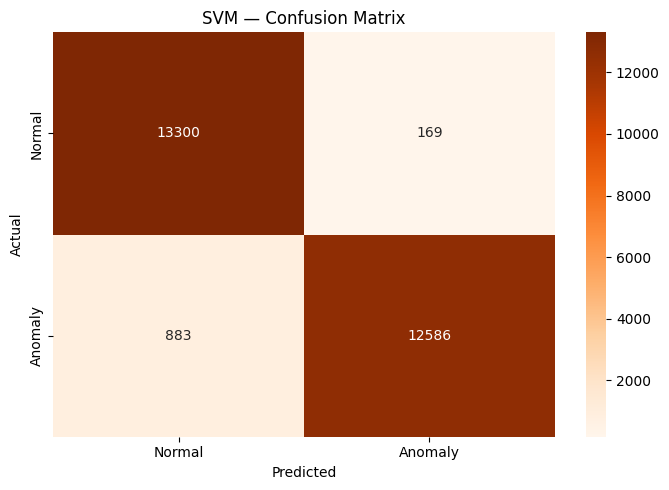


False Positive Rate: 1.25%


In [7]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('SVM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/svm_confusion_matrix.png')
plt.show()

FP = cm[0][1]
TN = cm[0][0]
FPR = FP / (FP + TN) * 100
print(f"\nFalse Positive Rate: {FPR:.2f}%")

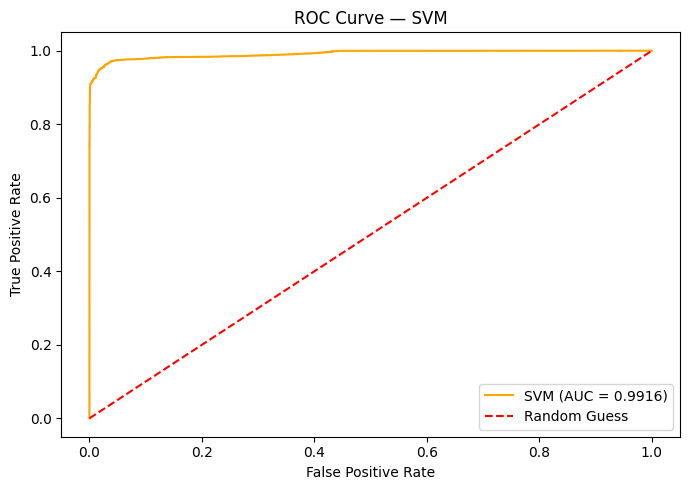

In [8]:
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc_score   = roc_auc_score(y_val, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='orange', label=f'SVM (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve — SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/svm_roc_curve.png')
plt.show()

In [9]:
os.makedirs('../models', exist_ok=True)
joblib.dump(svm_model, '../models/svm_model.pkl')
print("✅ SVM model saved to models/svm_model.pkl")

✅ SVM model saved to models/svm_model.pkl
